In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
data=pd.read_csv(r"C:\Users\Pavan\Desktop\healthcare_project\data\raw\healthcare_raw1.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   object 
 1   Age                      5000 non-null   int64  
 2   Sex                      5000 non-null   object 
 3   Race_Ethnicity           5000 non-null   object 
 4   Education_Level          5000 non-null   object 
 5   Income_Level             5000 non-null   object 
 6   Smoking_Status           5000 non-null   int64  
 7   Alcohol_Consumption      5000 non-null   int64  
 8   Physical_Activity_Level  5000 non-null   object 
 9   Sleep_Duration_Hours     5000 non-null   float64
 10  Height_cm                5000 non-null   float64
 11  Weight_kg                5000 non-null   float64
 12  BMI                      5000 non-null   float64
 13  BMI_Category             5000 non-null   object 
 14  Waist_Circumference_cm  

In [7]:
data.head()

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Mortality,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score
0,PAT200000,84,Male,White,Secondary,Low,0,0,High,7.1,...,0,9700,2023-04-02 08:00:00,2023-04-02,8,Sunday,75+,1,0,4
1,PAT200001,35,Male,White,Graduate,High,0,1,Moderate,4.8,...,0,9700,2023-03-19 16:00:00,2023-03-19,16,Sunday,31-45,0,1,2
2,PAT200002,75,Female,Asian,Secondary,Middle,1,0,Moderate,5.7,...,0,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4
3,PAT200003,65,Male,Hispanic,Graduate,Low,0,1,Moderate,7.8,...,0,13300,2023-11-05 02:00:00,2023-11-05,2,Sunday,61-75,0,0,0
4,PAT200004,50,Female,White,Primary,High,0,0,Moderate,5.6,...,0,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1


In [9]:
gender=data["Sex"].value_counts()
gender

Sex
Female    2483
Male      2419
Other       98
Name: count, dtype: int64

In [47]:
data["Sex"]=data["Sex"].map({"Male":1,"Female":0,"Other":2})

In [49]:
data.head(20)

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Mortality,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score
0,PAT200000,84,1,White,Secondary,Low,0,0,High,7.1,...,0,9700,2023-04-02 08:00:00,2023-04-02,8,Sunday,75+,1,0,4
1,PAT200001,35,1,White,Graduate,High,0,1,Moderate,4.8,...,0,9700,2023-03-19 16:00:00,2023-03-19,16,Sunday,31-45,0,1,2
2,PAT200002,75,0,Asian,Secondary,Middle,1,0,Moderate,5.7,...,0,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4
3,PAT200003,65,1,Hispanic,Graduate,Low,0,1,Moderate,7.8,...,0,13300,2023-11-05 02:00:00,2023-11-05,2,Sunday,61-75,0,0,0
4,PAT200004,50,0,White,Primary,High,0,0,Moderate,5.6,...,0,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1
5,PAT200005,64,1,White,Secondary,Middle,0,1,Moderate,8.2,...,0,6100,2024-06-06 12:00:00,2024-06-06,12,Thursday,61-75,1,0,2
6,PAT200006,43,0,Hispanic,Primary,High,1,0,High,7.9,...,0,20500,2024-02-17 23:00:00,2024-02-17,23,Saturday,31-45,1,0,2
7,PAT200007,54,1,Black,Secondary,Middle,0,0,Low,8.6,...,0,15100,2024-09-07 14:00:00,2024-09-07,14,Saturday,46-60,1,1,3
8,PAT200008,86,0,Hispanic,Secondary,Middle,0,1,Low,7.8,...,0,9700,2023-11-02 17:00:00,2023-11-02,17,Thursday,75+,0,1,1
9,PAT200009,67,0,Black,Postgraduate,Low,0,0,Moderate,5.6,...,0,11500,2023-06-16 16:00:00,2023-06-16,16,Friday,61-75,0,1,1


In [237]:
gender=data["Sex"].value_counts()
gender

Sex
0    2483
1    2419
2      98
Name: count, dtype: int64

In [243]:
max_age=data["Age"].max()
max_age

89

In [253]:
max_bmi=data["BMI"].min()
max_bmi

3.9

In [401]:
smoking=data["Smoking_Status"].value_counts()
smoking

Smoking_Status
0    3880
1    1120
Name: count, dtype: int64

In [289]:
data[data["Alcohol_Consumption"]==1].groupby("Sex")["Alcohol_Consumption"].size()


Sex
0    705
1    639
2     28
Name: Alcohol_Consumption, dtype: int64

In [303]:
count=data[(data["Smoking_Status"]==0) & (data["Age"]>40)].shape[0]
count

2639

In [337]:
max_age=data[data["Smoking_Status"]==0] ["Age"].min()
max_age

18

In [381]:
race=data["Race_Ethnicity"].value_counts()
race

Race_Ethnicity
White       1904
Asian       1081
Black        886
Hispanic     861
Other        268
Name: count, dtype: int64

In [377]:
race_age=data[(data["Race_Ethnicity"]=="White")& (data["Sex"]==2)].shape[0]
race_age

30

In [13]:
race_sex_dist=pd.crosstab(data["Race_Ethnicity"],data["Sex"])
race_sex_dist

Sex,Female,Male,Other
Race_Ethnicity,,,
Asian,521,535,25
Black,443,423,20
Hispanic,447,397,17
Other,132,130,6
White,940,934,30


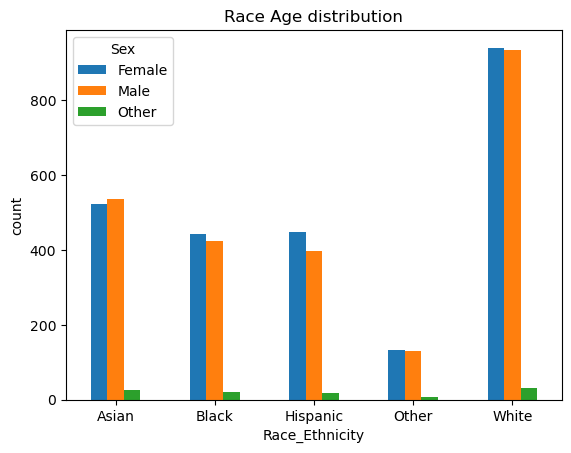

In [13]:
race_sex_dist.plot(kind="bar")
plt.title("Race Age distribution")
plt.ylabel("count")
plt.xticks(rotation=360)
plt.show()

In [15]:
diag_sex=pd.crosstab(data["Primary_Diagnosis"],data["Sex"],normalize="columns")*100
diag_sex

Sex,Female,Male,Other
Primary_Diagnosis,,,
Cardiac,12.243254,12.608516,10.204082
Diabetes,18.364881,16.659777,20.408163
Hypertension,21.224325,23.811492,16.326531
Infection,14.176400,13.063249,8.163265
Neurology,8.336689,7.771807,12.244898
Orthopedic,5.436971,6.821000,7.142857
Other,5.960532,6.200909,5.102041
Respiratory,14.256947,13.063249,20.408163


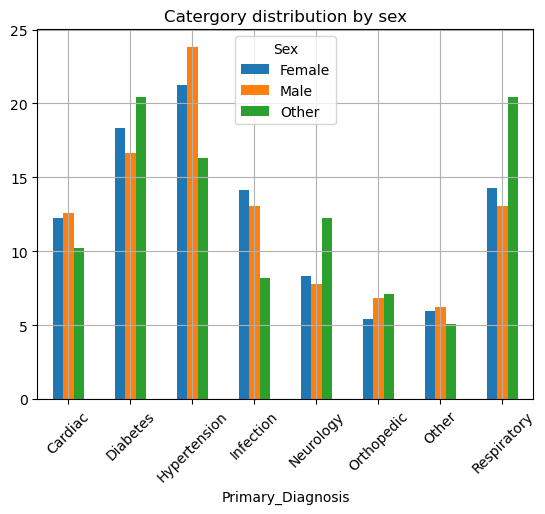

In [17]:
diag_sex.plot(kind="bar")
plt.title("Catergory distribution by sex")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [467]:
smoke_sex=pd.crosstab(data["Smoking_Status"],data["Sex"])
smoke_sex

Sex,Female,Male,Other
Smoking_Status,,,
0,1943,1860,77
1,540,559,21


In [19]:
data["high_risk"]=data[(data["Age"]>65)& (data["ICU_Required"]==1) &(data["Comorbidity_Score"]>=2)].shape[0]
data["high_risk"].value_counts()

high_risk
184    5000
Name: count, dtype: int64

In [21]:
Avg_bill=data.groupby("high_risk")["Total_Bill_Amount"].mean()
Avg_bill

high_risk
184    12367.36
Name: Total_Bill_Amount, dtype: float64

In [23]:
data["top_10%_bill"]=data["Total_Bill_Amount"]%100
data["top_10%_bill"].value_counts()

top_10%_bill
0    5000
Name: count, dtype: int64

In [25]:
data_sorted=data.sort_values(by="Total_Bill_Amount",ascending=False)


In [27]:
Total_cost=data_sorted["Total_Bill_Amount"].sum()
Total_cost

61836800

In [29]:
top_10_percent_count=int(0.10*len(data_sorted))
top_10_cost=data_sorted.head(top_10_percent_count)["Total_Bill_Amount"].sum()
top_10_percentage=(top_10_cost/Total_cost)*100
top_10_percentage

23.43200165597185

In [545]:
data.columns

Index(['Patient_ID', 'Age', 'Sex', 'Race_Ethnicity', 'Education_Level',
       'Income_Level', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Sleep_Duration_Hours', 'Height_cm',
       'Weight_kg', 'BMI', 'BMI_Category', 'Waist_Circumference_cm',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Respiratory_Rate',
       'Body_Temperature_C', 'SpO2', 'Glucose_mg_dL', 'HbA1c_percent',
       'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL',
       'Triglycerides_mg_dL', 'Hemoglobin_g_dL', 'WBC_Count',
       'Creatinine_mg_dL', 'Sodium_mEq_L', 'Diabetes', 'Hypertension',
       'Heart_Disease', 'Kidney_Disease', 'Respiratory_Disease',
       'Stroke_History', 'Primary_Diagnosis', 'ICU_Required',
       'Length_of_Stay_Days', 'Readmitted_30_Days', 'Mortality',
       'Total_Bill_Amount', 'Admission_Time', 'Admission_Date',
       'Admission_Hour', 'Day_of_Week', 'Age_Group', 'High_BP_Flag',
       'High_Glucose_Flag', 'Comorbidity_Score', 'high_risk', '

In [579]:
icu_admission=pd.crosstab(data["ICU_Required"],data["Age"])
icu_admission

Age,18,19,20,21,22,23,24,25,26,27,...,80,81,82,83,84,85,86,87,88,89
ICU_Required,,,,,,,,,,,,,,,,,,,,,
0,58,58,67,62,54,57,50,55,55,42,...,68,58,53,63,56,47,54,71,53,58
1,9,9,17,12,8,12,9,7,19,9,...,9,15,5,11,14,11,18,10,9,11


In [583]:
icu_sex=pd.crosstab(data["ICU_Required"],data["Sex"])
icu_sex

Sex,Female,Male,Other
ICU_Required,,,
0,2106,2058,78
1,377,361,20


In [589]:
icu_diagnosis=pd.crosstab(data["ICU_Required"],data["Primary_Diagnosis"])
icu_diagnosis

Primary_Diagnosis,Cardiac,Diabetes,Hypertension,Infection,Neurology,Orthopedic,Other,Respiratory
ICU_Required,,,,,,,,
0,480,771,988,588,316,275,270,554
1,139,108,131,88,91,32,33,136


In [607]:
data["Highes_icu_group"]=data[(data["ICU_Required"]==1)&(data["Sex"]==("Female"))].shape[0]
data["Highes_icu_group"].value_counts()

Highes_icu_group
377    5000
Name: count, dtype: int64

In [609]:
data["Length_of_Stay_Days"].max()

16

In [623]:
icu_nonicu=pd.crosstab(data["Length_of_Stay_Days"],data["ICU_Required"])
icu_nonicu

ICU_Required,0,1
Length_of_Stay_Days,,
1,202,0
2,648,0
3,941,0
4,984,40
5,686,94
6,416,170
7,215,169
8,100,127
9,33,80


In [629]:
icu_Diagnosis=pd.crosstab(data["Length_of_Stay_Days"],data["Primary_Diagnosis"])
icu_Diagnosis

Primary_Diagnosis,Cardiac,Diabetes,Hypertension,Infection,Neurology,Orthopedic,Other,Respiratory
Length_of_Stay_Days,,,,,,,,
1,24,43,36,34,20,11,13,21
2,70,122,151,72,48,48,36,101
3,115,162,206,127,58,74,71,128
4,111,191,250,157,74,63,57,121
5,94,150,166,109,62,44,55,100
6,85,91,147,75,55,24,23,86
7,52,47,75,44,52,22,29,63
8,40,36,49,35,14,12,10,31
9,15,21,23,10,14,4,1,25


In [635]:
icu_com_score=pd.crosstab(data["Length_of_Stay_Days"],data['Comorbidity_Score'])
icu_com_score

Comorbidity_Score,0,1,2,3,4,5,6
Length_of_Stay_Days,,,,,,,
1,13,57,59,38,25,10,0
2,55,169,209,115,74,25,1
3,72,248,275,152,171,22,1
4,73,299,320,152,159,21,0
5,66,243,230,112,121,7,1
6,37,174,174,89,98,13,1
7,30,111,114,62,59,8,0
8,15,62,77,39,26,7,1
9,12,21,44,21,13,2,0


In [31]:
riskscore=data[(data["Age"])&(data["Diabetes"]==1)&(data["SpO2"].max())&(data["Creatinine_mg_dL"])].shape[0]
riskscore

1603

Admission_Date
2023-01-01     7
2023-01-02     6
2023-01-03    11
2023-01-04     5
2023-01-05     8
              ..
2024-11-26    10
2024-11-27     5
2024-11-28     4
2024-11-29     8
2024-11-30     5
Name: Patient_ID, Length: 698, dtype: int64


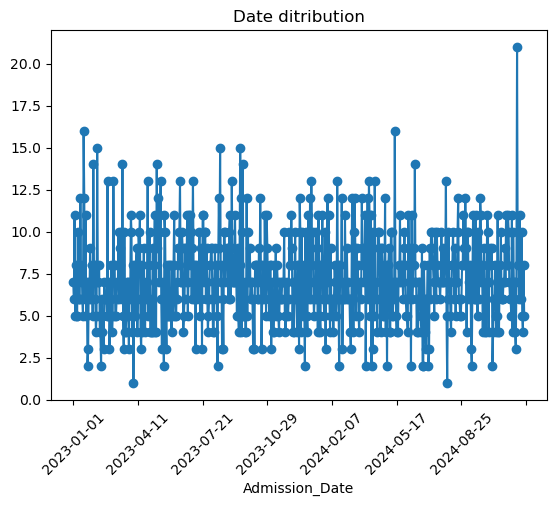

In [45]:
date_ditribution=data.groupby('Admission_Date')['Patient_ID'].size()
print(date_ditribution)
date_ditribution.plot(kind="line",marker="o")
plt.title("Date ditribution")
plt.xticks(rotation=45)
plt.show()

In [67]:
data["Amdmission_year"]=pd.to_datetime(data["Admission_Date"]).dt.year
print(data["Amdmission_year"].value_counts())

Amdmission_year
2023    2577
2024    2423
Name: count, dtype: int64


In [69]:
data.columns

Index(['Patient_ID', 'Age', 'Sex', 'Race_Ethnicity', 'Education_Level',
       'Income_Level', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Sleep_Duration_Hours', 'Height_cm',
       'Weight_kg', 'BMI', 'BMI_Category', 'Waist_Circumference_cm',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Respiratory_Rate',
       'Body_Temperature_C', 'SpO2', 'Glucose_mg_dL', 'HbA1c_percent',
       'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL',
       'Triglycerides_mg_dL', 'Hemoglobin_g_dL', 'WBC_Count',
       'Creatinine_mg_dL', 'Sodium_mEq_L', 'Diabetes', 'Hypertension',
       'Heart_Disease', 'Kidney_Disease', 'Respiratory_Disease',
       'Stroke_History', 'Primary_Diagnosis', 'ICU_Required',
       'Length_of_Stay_Days', 'Readmitted_30_Days', 'Mortality',
       'Total_Bill_Amount', 'Admission_Time', 'Admission_Date',
       'Admission_Hour', 'Day_of_Week', 'Age_Group', 'High_BP_Flag',
       'High_Glucose_Flag', 'Comorbidity_Score', 'Amdmission_ye

In [103]:
admission_diag=pd.crosstab(data['Amdmission_year'], data['Primary_Diagnosis'])
admission_diag

Primary_Diagnosis,Cardiac,Diabetes,Hypertension,Infection,Neurology,Orthopedic,Other,Respiratory
Amdmission_year,,,,,,,,
2023,305,476,576,373,193,159,147,348
2024,314,403,543,303,214,148,156,342


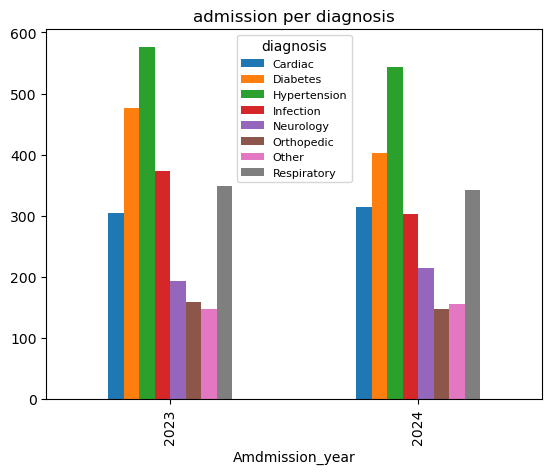

In [137]:
admission_diag.plot(kind="bar")
plt.title("admission per diagnosis")
plt.legend(title="diagnosis",loc="upper center", fontsize=8)
plt.show()

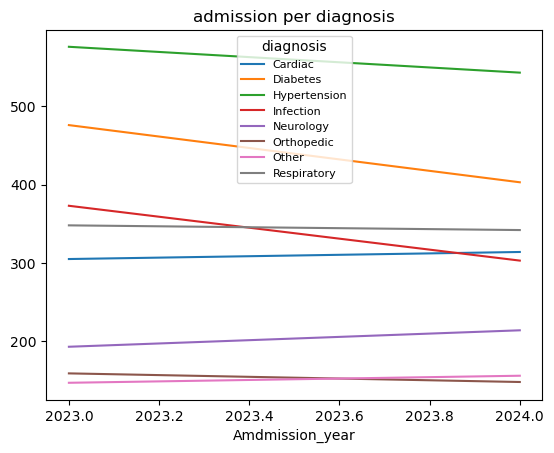

In [139]:
admission_diag.plot(kind="line")
plt.title("admission per diagnosis")
plt.legend(title="diagnosis",loc="upper center", fontsize=8)
plt.show()

In [141]:
admission_sex=pd.crosstab(data['Amdmission_year'], data['Sex'])
admission_sex

Sex,Female,Male,Other
Amdmission_year,,,
2023,1286,1237,54
2024,1197,1182,44


In [143]:
diag_sex=pd.crosstab(data['Primary_Diagnosis'],data["Sex"])
diag_sex

Sex,Female,Male,Other
Primary_Diagnosis,,,
Cardiac,304,305,10
Diabetes,456,403,20
Hypertension,527,576,16
Infection,352,316,8
Neurology,207,188,12
Orthopedic,135,165,7
Other,148,150,5
Respiratory,354,316,20


In [184]:
higest_bill=data["Total_Bill_Amount"].max()
higest_bill

43300

In [276]:
Duplicates=data["Patient_ID"].duplicated().any()
Duplicates

False

In [274]:
Duplicates.sum()

0

In [288]:
Duplicates=data[data["Patient_ID"].duplicated(keep=False)]
Duplicates

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score,Amdmission_year,higest_bill


In [35]:
invalid_rows = data[
    (data["Age"] < 18) | (data["Age"] > 90) |
    (data["SpO2"] < 85) | (data["SpO2"] > 100) |
    (data["BMI"] < 10) | (data["BMI"] > 60)
]
invalid_rows.shape[0]

10

In [37]:
invalid_rows[["Age","SpO2","BMI"]].head(10)

,Age,SpO2,BMI
660,66,99,8.4
814,54,99,8.3
1672,28,85,7.5
1945,80,90,8.1
2476,57,99,6.2
3303,45,85,9.1
3315,75,93,9.6
3364,61,98,3.9
3820,24,87,9.9
4445,88,95,9.4


In [39]:
invalid_summary = {
    "Invalid_Age": data[(data["Age"] < 18) | (data["Age"] > 90)].shape[0],
    "Invalid_SpO2": data[(data["SpO2"] < 85) | (data["SpO2"] > 100)].shape[0],
    "Invalid_BMI": data[(data["BMI"] < 10) | (data["BMI"] > 60)].shape[0],
}

invalid_summary


{'Invalid_Age': 0, 'Invalid_SpO2': 0, 'Invalid_BMI': 10}

In [41]:
icu_avg_age=data.groupby("ICU_Required")["Age"].mean()
icu_avg_age

ICU_Required
0    53.575672
1    52.865435
Name: Age, dtype: float64

In [43]:
icu_avg_LOS=data.groupby("ICU_Required")['Length_of_Stay_Days'].mean()
icu_avg_LOS

ICU_Required
0    3.998114
1    7.118734
Name: Length_of_Stay_Days, dtype: float64

In [350]:
icu_avg_bill=data.groupby("ICU_Required")["Total_Bill_Amount"].mean()
icu_avg_bill

ICU_Required
0     9696.605375
1    27313.720317
Name: Total_Bill_Amount, dtype: float64

In [318]:
diag_wise_compare=data.groupby("Primary_Diagnosis").agg(
    icu_rate=("ICU_Required","mean"),
    Average_LOs=('Length_of_Stay_Days',"mean"),
    average_bill=("Total_Bill_Amount","mean")
    
)

In [310]:
diag_wise_compare

,icu_rate,Average_LOs,average_bill
Primary_Diagnosis,,,
Cardiac,0.224556,4.663974,13589.822294
Diabetes,0.122867,4.329920,11768.259386
Hypertension,0.117069,4.432529,11883.378016
Infection,0.130178,4.428994,12034.319527
Neurology,0.223587,4.754300,13740.786241
Orthopedic,0.104235,4.185668,11285.016287
Other,0.108911,4.359736,11654.455446
Respiratory,0.197101,4.591304,13129.565217


In [342]:
icu_required=pd.crosstab(data["ICU_Required"],data["Sex"])
icu_required

Sex,Female,Male,Other
ICU_Required,,,
0,2106,2058,78
1,377,361,20


In [55]:
average_bill_sex=data.groupby("Sex")["Total_Bill_Amount"].mean()

average_bill_sex

Sex
Female    12326.661297
Male      12380.033072
Other     13085.714286
Name: Total_Bill_Amount, dtype: float64

In [380]:
average_smoke_sex=data.groupby("Sex")["Smoking_Status"].mean()*100
average_smoke_sex

Sex
Female    21.747886
Male      23.108723
Other     21.428571
Name: Smoking_Status, dtype: float64

In [384]:
average_alocohol_sex=data.groupby("Sex")["Alcohol_Consumption"].mean()*100
average_alocohol_sex

Sex
Female    28.393073
Male      26.415874
Other     28.571429
Name: Alcohol_Consumption, dtype: float64

In [73]:
sex_summary = data.groupby("Sex").agg(
    Average_Bill=("Total_Bill_Amount", "mean"),
    Smoking_Percent=("Smoking_Status", "mean"),
    Alcohol_Percent=("Alcohol_Consumption", "mean")
)

# Convert to percentage
sex_summary["Smoking_Percent"] *=100
sex_summary["Alcohol_Percent"] *=100

sex_summary.round(2)


,Average_Bill,Smoking_Percent,Alcohol_Percent
Sex,,,
Female,12326.66,21.75,28.39
Male,12380.03,23.11,26.42
Other,13085.71,21.43,28.57


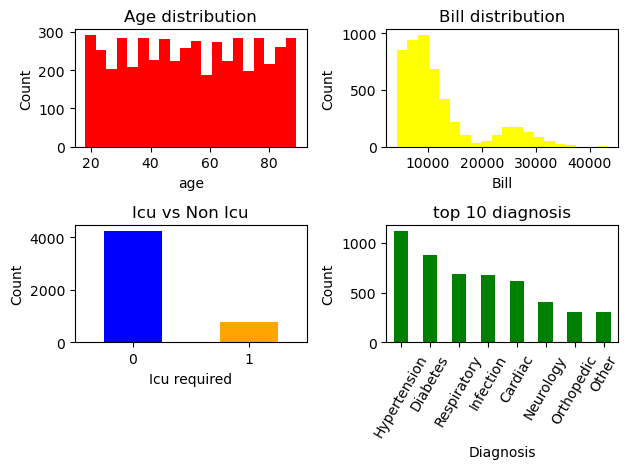

In [45]:
fig,ax=plt.subplots(2,2)

ax[0,0].hist(data["Age"],bins=20, color="red")
ax[0,0].set_title("Age distribution")
ax[0,0].set_xlabel("age")
ax[0,0].set_ylabel("Count")

ax[0,1].hist(data["Total_Bill_Amount"], bins=20,color="yellow")
ax[0,1].set_title("Bill distribution")
ax[0,1].set_xlabel("Bill")
ax[0,1].set_ylabel("Count")

data["ICU_Required"].value_counts().plot(kind="bar", ax=ax[1,0],color=("blue","orange"))
ax[1,0].set_title("Icu vs Non Icu")
ax[1,0].set_xlabel("Icu required")
ax[1,0].set_ylabel("Count")
ax[1,0].tick_params(axis="x",rotation=360)

data["Primary_Diagnosis"].value_counts().head(10).plot(kind="bar", ax=ax[1,1],color="green")
ax[1,1].set_title("top 10 diagnosis")
ax[1,1].set_xlabel("Diagnosis")
ax[1,1].set_ylabel("Count")
ax[1,1].tick_params(axis="x",rotation=60)


plt.tight_layout()
plt.show()

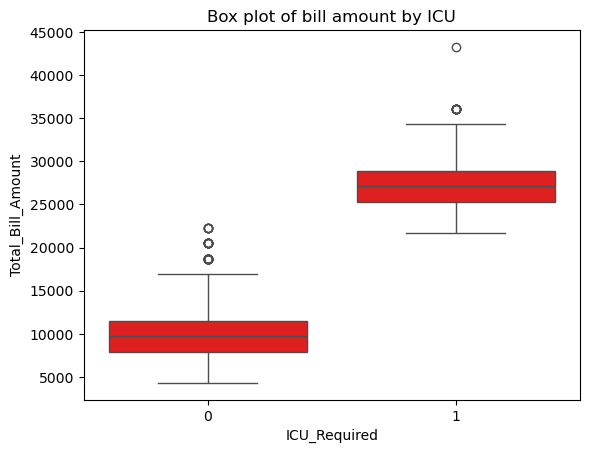

In [47]:
sns.boxplot(x="ICU_Required",y="Total_Bill_Amount",data=data, color=("red"))
plt.title("Box plot of bill amount by ICU")
plt.show()

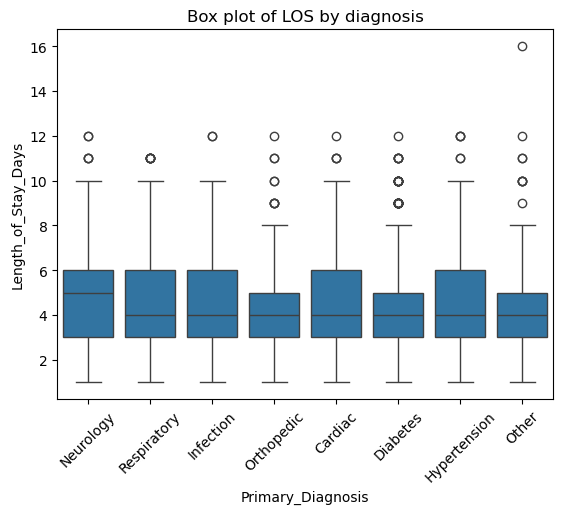

In [49]:
sns.boxplot(x="Primary_Diagnosis",y="Length_of_Stay_Days",data=data)
plt.title("Box plot of LOS by diagnosis")
plt.xticks(rotation=45)
plt.show()

In [53]:
age_bins=[18,30,45,60,data["Age"].max()]
age_labels=["18–30", "31–45", "46–60", "60+"]
data["Age_Band"]=pd.cut(
    data["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True         
)

In [55]:
bill_bins=[
    data["Total_Bill_Amount"].min(),
    data["Total_Bill_Amount"].quantile(0.33),
    data["Total_Bill_Amount"].quantile(0.66),
    data["Total_Bill_Amount"].max(),
]
bill_labels=["low","medium","high"]
data["bill_band"]=pd.cut(
    data["Total_Bill_Amount"],
    bins=bill_bins,
    labels=bill_labels,
     include_lowest=True 
    
)

In [57]:
data["Age_Band"].value_counts()

Age_Band
60+      2024
31–45    1083
46–60    1006
18–30     887
Name: count, dtype: int64

In [59]:
data["bill_band"].value_counts()

bill_band
low       1791
medium    1670
high      1539
Name: count, dtype: int64

In [61]:
band_age_bill=pd.crosstab(data["bill_band"],data["Age_Band"])
band_age_bill

Age_Band,18–30,31–45,46–60,60+
bill_band,,,,
low,279,391,366,755
medium,304,370,324,672
high,304,322,316,597


In [63]:
features=["Age","Diabetes","Hypertension","SpO2","Creatinine_mg_dL"]
x=data[features]
y=data["ICU_Required"]


In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y, test_size=0.2,
    random_state=42
)

In [67]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [69]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

In [77]:
y_pred=model.predict(x_test)

In [43]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.851


In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[851,   0],
       [149,   0]], dtype=int64)

In [51]:
importnace=pd.Series(
    model.coef_[0],
    index=features,
).sort_values(ascending=False)
print(importnace)

Hypertension        0.014453
Diabetes            0.006474
Creatinine_mg_dL   -0.033222
Age                -0.059478
SpO2               -0.510566
dtype: float64


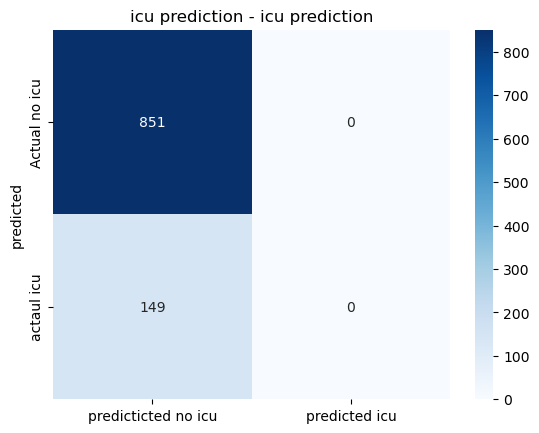

In [63]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["predicticted no icu","predicted icu"],
    yticklabels=["Actual no icu","actaul icu"]

)
plt.title("icu prediction - icu prediction")
plt.ylabel("actual")
plt.ylabel("predicted")
plt.show()

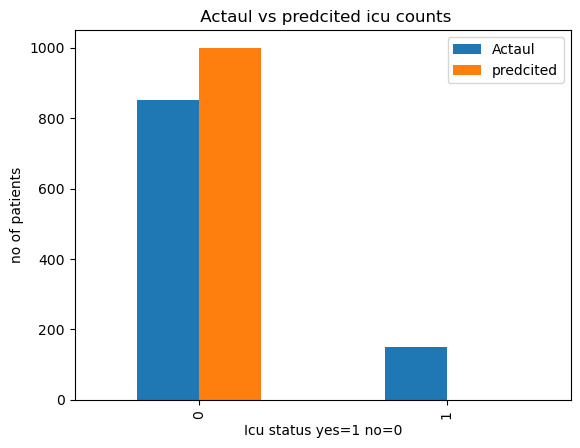

In [69]:
comparison_data=pd.DataFrame({
    "Actaul":y_test.value_counts().sort_index(),
    "predcited":pd.Series(y_pred).value_counts().sort_index()
})
comparison_data.plot(kind="bar")
plt.title(" Actaul vs predcited icu counts")
plt.xlabel("Icu status yes=1 no=0")
plt.ylabel("no of patients")
plt.show()

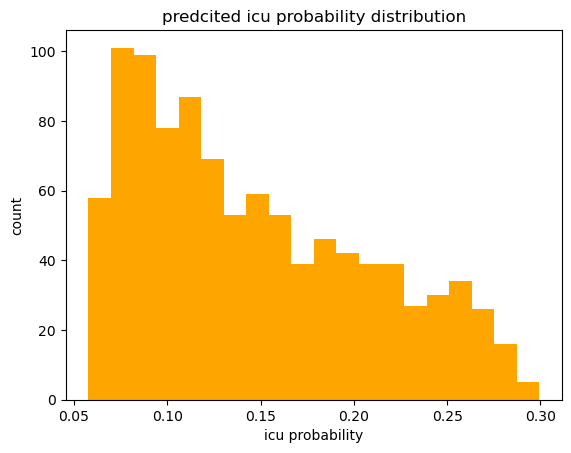

In [99]:
y_prob=model.predict_proba(x_test)[:,1]
plt.hist(y_prob,bins=20, color="orange")
plt.title("predcited icu probability distribution")
plt.xlabel("icu probability")
plt.ylabel("count")
plt.show()

In [89]:
data["ICU_Required"].value_counts()

ICU_Required
0    4242
1     758
Name: count, dtype: int64

In [91]:
data[["Age","SpO2","Diabetes","Hypertension"]].head()

,Age,SpO2,Diabetes,Hypertension
0,84,94,1,1
1,35,88,1,1
2,75,89,0,1
3,65,89,0,0
4,50,86,0,1


In [93]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [95]:
y_pred=model.predict(x_test)

In [105]:
data[["Age","SpO2","Diabetes","Hypertension"]].isnull().sum()

Age             0
SpO2            0
Diabetes        0
Hypertension    0
dtype: int64

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report,roc_auc_score,roc_curve, r2_score



In [175]:
data["Sex"].value_counts()

Sex
Female    2483
Male      2419
Other       98
Name: count, dtype: int64

In [71]:
data["Sex"]=data["Sex"].map({"Female":0,"Male":1,"Other":2})

In [73]:
data["Sex"].value_counts()

Sex
0    2483
1    2419
2      98
Name: count, dtype: int64

In [181]:
age_bins=[18,30,45,60,data["Age"].max()]
age_labels=["18-30","30-45","45-60","60+"]
age_summary=pd.cut(
    data["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [268]:
age_summary.value_counts()

Age
60+      2024
30-45    1083
45-60    1006
18-30     887
Name: count, dtype: int64

In [274]:
low_spo2_flag=(data["SpO2"]<92).astype(int)
high_age_flag=(data["Age"]>65).astype(int)
high_bill_flag=(data["Total_Bill_Amount"]>data["Total_Bill_Amount"].quantile(0.75)).astype(int)

In [205]:
low_spo2_flag.sum()

2363

In [212]:
high_age_flag.sum()

1680

In [216]:
high_bill_flag.sum()

1123

In [266]:
comorbidirty_count=(data["Diabetes"]+data["Hypertension"])
comorbidirty_count.sum()

6952

In [125]:
data["simple_risk_score"]=(
    (data["SpO2"]<92).astype(int)+
    (data["Age"]>65).astype(int)+
    data["Diabetes"]+
    data["Hypertension"]
       
)

In [244]:
data.groupby("simple_risk_score")["ICU_Required"].mean()*100

simple_risk_score
0    11.309524
1    10.085837
2    14.500753
3    18.891038
4    17.696629
Name: ICU_Required, dtype: float64

In [47]:
data[data["Age"]>60].shape[0]

2024

In [45]:
data[data["ICU_Required"]==1].shape[0]

758

In [43]:
age_female=data[(data["Sex"]=="Female")&(data["Age"]>60)]
age_female.shape[0]

1006

In [77]:
data[(data["Smoking_Status"]==1)|(data["Alcohol_Consumption"])==1].shape[0]

2206

In [81]:
data[data["Primary_Diagnosis"].isin(["Diabetes","Hypertension"])].shape[0]

1998

In [95]:
data[data["Age"].between(30,50)].shape[0]

1504

In [109]:
data.loc[data["ICU_Required"]==1, ["Age","Total_Bill_Amount"]].head(40)

,Age,Total_Bill_Amount
2,75,23500
14,84,34300
15,65,30700
24,87,25300
30,36,28900
35,88,28900
37,24,28900
42,61,21700
47,74,25300
59,29,27100


In [123]:
data[(data["Age"]>65)& (data["ICU_Required"]==1)].shape[0]

242

In [17]:
data.iloc[0:5]

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Mortality,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score
0,PAT200000,84,1,White,Secondary,Low,0,0,High,7.1,...,0,9700,2023-04-02 08:00:00,2023-04-02,8,Sunday,75+,1,0,4
1,PAT200001,35,1,White,Graduate,High,0,1,Moderate,4.8,...,0,9700,2023-03-19 16:00:00,2023-03-19,16,Sunday,31-45,0,1,2
2,PAT200002,75,0,Asian,Secondary,Middle,1,0,Moderate,5.7,...,0,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4
3,PAT200003,65,1,Hispanic,Graduate,Low,0,1,Moderate,7.8,...,0,13300,2023-11-05 02:00:00,2023-11-05,2,Sunday,61-75,0,0,0
4,PAT200004,50,0,White,Primary,High,0,0,Moderate,5.6,...,0,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1


In [165]:
data.loc[(data["Sex"]=="Male") & (data["ICU_Required"]==1),["Age","Total_Bill_Amount"]].head(10)

,Age,Total_Bill_Amount
14,84,34300
15,65,30700
35,88,28900
42,61,21700
47,74,25300
67,88,28900
79,33,23500
90,48,23500
95,62,28900
96,69,28900


In [167]:
data.head(5)

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score,simple_risk_score
0,PAT200000,84,Male,White,Secondary,Low,0,0,High,7.1,...,9700,2023-04-02 08:00:00,2023-04-02,8,Sunday,75+,1,0,4,3
1,PAT200001,35,Male,White,Graduate,High,0,1,Moderate,4.8,...,9700,2023-03-19 16:00:00,2023-03-19,16,Sunday,31-45,0,1,2,3
2,PAT200002,75,Female,Asian,Secondary,Middle,1,0,Moderate,5.7,...,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4,3
3,PAT200003,65,Male,Hispanic,Graduate,Low,0,1,Moderate,7.8,...,13300,2023-11-05 02:00:00,2023-11-05,2,Sunday,61-75,0,0,0,1
4,PAT200004,50,Female,White,Primary,High,0,0,Moderate,5.6,...,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1,2


In [193]:
data["Admission_Time"]=pd.to_datetime(data["Admission_Time"],format="%d-%m-%y %I:%M %p")

In [197]:
data["Admission_Time"]

0      2023-04-02 08:00:00
1      2023-03-19 16:00:00
2      2024-10-31 22:00:00
3      2023-11-05 02:00:00
4      2023-10-18 19:00:00
               ...        
4995   2023-01-06 22:00:00
4996   2023-05-05 01:00:00
4997   2023-08-02 08:00:00
4998   2024-07-12 15:00:00
4999   2023-05-16 08:00:00
Name: Admission_Time, Length: 5000, dtype: datetime64[ns]

In [209]:
data["Admission_Time"]=pd.to_datetime(data["Admission_Time"], errors="coerce")

In [211]:
data["Admission_Time"]

0      2023-04-02 08:00:00
1      2023-03-19 16:00:00
2      2024-10-31 22:00:00
3      2023-11-05 02:00:00
4      2023-10-18 19:00:00
               ...        
4995   2023-01-06 22:00:00
4996   2023-05-05 01:00:00
4997   2023-08-02 08:00:00
4998   2024-07-12 15:00:00
4999   2023-05-16 08:00:00
Name: Admission_Time, Length: 5000, dtype: datetime64[ns]

In [219]:
data["Admission_date"]=pd.to_datetime(data["Admission_Time"]).dt.date
data["Admission_Hour"]=pd.to_datetime(data["Admission_Time"]).dt.hour

In [225]:
hourly_admissions=data["Admission_Hour"].value_counts().sort_index()
hourly_admissions

Admission_Hour
0     198
1     195
2     213
3     200
4     200
5     226
6     238
7     215
8     207
9     189
10    208
11    195
12    210
13    211
14    214
15    211
16    217
17    219
18    189
19    206
20    212
21    200
22    207
23    220
Name: count, dtype: int64

In [227]:
hourly_admissions.idxmax()

6

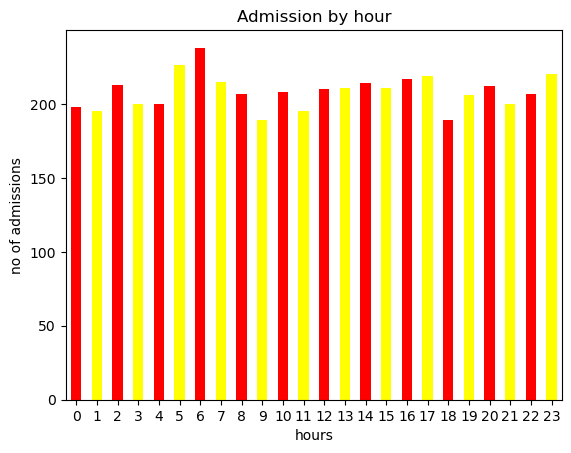

In [253]:
hourly_admissions.plot(kind="bar",color=("red","yellow"))
plt.title("Admission by hour")
plt.xlabel("hours")
plt.ylabel("no of admissions")
plt.xticks(rotation=0)
plt.show()

In [235]:
day_admissions=data["Admission_date"].value_counts().sort_index()
day_admissions

Admission_date
2023-01-01     7
2023-01-02     6
2023-01-03    11
2023-01-04     5
2023-01-05     8
              ..
2024-11-26    10
2024-11-27     5
2024-11-28     4
2024-11-29     8
2024-11-30     5
Name: count, Length: 698, dtype: int64

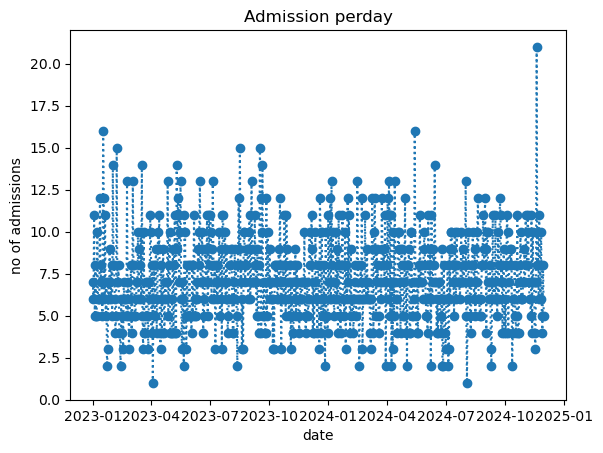

In [275]:
day_admissions.plot(kind="line",marker="o",linestyle="dotted")
plt.title("Admission perday")
plt.xlabel("date")
plt.ylabel("no of admissions")
plt.xticks(rotation=0)
plt.show()

In [245]:
icu_rate_hour=data.groupby("Admission_Hour")["ICU_Required"].mean()*100
icu_rate_hour

Admission_Hour
0     16.666667
1     15.897436
2     10.328638
3     14.000000
4     13.000000
5     15.929204
6     16.386555
7     13.023256
8     16.908213
9     19.576720
10    10.576923
11    20.512821
12    13.809524
13    16.113744
14    13.084112
15    13.744076
16    17.972350
17    14.611872
18    13.227513
19    15.533981
20    16.509434
21    16.500000
22    13.043478
23    17.272727
Name: ICU_Required, dtype: float64

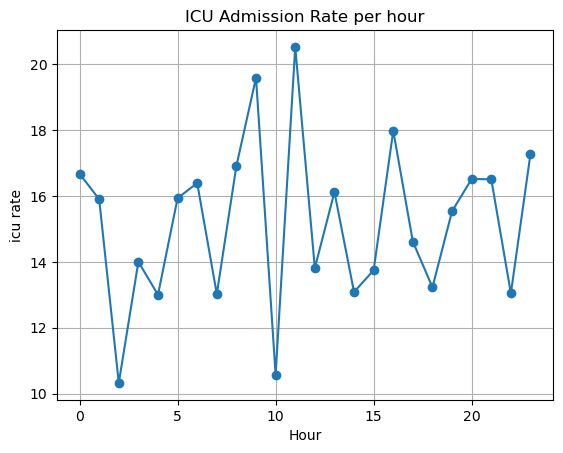

In [297]:
icu_rate_hour.plot(kind="line",marker="o")
plt.title("ICU Admission Rate per hour")
plt.xlabel("Hour")
plt.ylabel("icu rate")
plt.grid()
plt.show()

In [316]:
Average_bill=data.groupby("Sex")["Total_Bill_Amount"].mean()

In [318]:
Average_bill

Sex
Female    1.232666e+06
Male      1.238003e+06
Other     1.308571e+06
Name: Total_Bill_Amount, dtype: float64

In [324]:
Average_age_bill=data.groupby("Age_Band")["Total_Bill_Amount"].mean()

C:\Users\Pavan\AppData\Local\Temp\ipykernel_19072\3529044800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Average_age_bill=data.groupby("Age_Band")["Total_Bill_Amount"].mean()


In [326]:
Average_age_bill

Age_Band
18–30    12932.694476
31–45    12257.894737
46–60    12280.119284
60+      12221.541502
Name: Total_Bill_Amount, dtype: float64

In [328]:
Average_diag_bill=data.groupby("Primary_Diagnosis")["Total_Bill_Amount"].mean()

In [330]:
Average_diag_bill

Primary_Diagnosis
Cardiac         13589.822294
Diabetes        11768.259386
Hypertension    11883.378016
Infection       12034.319527
Neurology       13740.786241
Orthopedic      11285.016287
Other           11654.455446
Respiratory     13129.565217
Name: Total_Bill_Amount, dtype: float64

In [342]:
data["risk_category"]=(
    (data["SpO2"]<92).astype(int)+
    (data["Age"]>65).astype(int)+
    (data["Hypertension"])+
    (data["Diabetes"])
)

data["risk_category"].value_counts()
              

risk_category
2    1993
3    1551
1     932
4     356
0     168
Name: count, dtype: int64

In [338]:
icu_rate=data.groupby("ICU_Required")["risk_category"].mean()*100

In [340]:
icu_rate

ICU_Required
0    216.690240
1    237.862797
Name: risk_category, dtype: float64

In [354]:
icu_rate_age=data.groupby("Age_Band")["ICU_Required"].mean()*100
icu_rate_age

C:\Users\Pavan\AppData\Local\Temp\ipykernel_19072\3573361489.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  icu_rate_age=data.groupby("Age_Band")["ICU_Required"].mean()*100


Age_Band
18–30    16.910936
31–45    14.958449
46–60    14.612326
60+      14.772727
Name: ICU_Required, dtype: float64

In [19]:
data[["Systolic_BP","Diastolic_BP"]].isnull().sum()

Systolic_BP     0
Diastolic_BP    0
dtype: int64

In [35]:
data["Blood_Pressure"]=(data["Systolic_BP"].astype(int).astype(str)+"/"+data["Diastolic_BP"].astype(int).astype(str))

In [37]:
data["Blood_Pressure"]

0        178/71
1        90/105
2        171/62
3        102/79
4       182/118
         ...   
4995     154/90
4996     167/78
4997    171/110
4998    181/108
4999     159/90
Name: Blood_Pressure, Length: 5000, dtype: object

In [55]:
data.head(5)

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Mortality,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score
0,PAT200000,84,1,White,Secondary,Low,0,0,High,7.1,...,0,9700,2023-04-02 08:00:00,2023-04-02,8,Sunday,75+,1,0,4
1,PAT200001,35,1,White,Graduate,High,0,1,Moderate,4.8,...,0,9700,2023-03-19 16:00:00,2023-03-19,16,Sunday,31-45,0,1,2
2,PAT200002,75,0,Asian,Secondary,Middle,1,0,Moderate,5.7,...,0,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4
3,PAT200003,65,1,Hispanic,Graduate,Low,0,1,Moderate,7.8,...,0,13300,2023-11-05 02:00:00,2023-11-05,2,Sunday,61-75,0,0,0
4,PAT200004,50,0,White,Primary,High,0,0,Moderate,5.6,...,0,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   object 
 1   Age                      5000 non-null   int64  
 2   Sex                      5000 non-null   int64  
 3   Race_Ethnicity           5000 non-null   object 
 4   Education_Level          5000 non-null   object 
 5   Income_Level             5000 non-null   object 
 6   Smoking_Status           5000 non-null   int64  
 7   Alcohol_Consumption      5000 non-null   int64  
 8   Physical_Activity_Level  5000 non-null   object 
 9   Sleep_Duration_Hours     5000 non-null   float64
 10  Height_cm                5000 non-null   float64
 11  Weight_kg                5000 non-null   float64
 12  BMI                      5000 non-null   float64
 13  BMI_Category             5000 non-null   object 
 14  Waist_Circumference_cm  

In [137]:
data["Blood_Pressure"].dtype

dtype('O')

In [79]:
features=["Sex","Age","Heart_Rate","Respiratory_Rate","SpO2","Systolic_BP","Diastolic_BP","Body_Temperature_C","Hemoglobin_g_dL","WBC_Count","Creatinine_mg_dL","Glucose_mg_dL","Hypertension","Diabetes"]

In [81]:
x=data[features]
y=data["ICU_Required"]

In [61]:
x

,Sex,Age,Heart_Rate,Respiratory_Rate,SpO2,Systolic_BP,Diastolic_BP,Body_Temperature_C,Hemoglobin_g_dL,WBC_Count,Creatinine_mg_dL,Glucose_mg_dL,Hypertension,Diabetes
0,1,84,91,28,94,178,71,36.7,12.7,7.6,0.45,146,1,1
1,1,35,63,13,88,90,105,36.1,15.7,4.1,1.21,205,1,1
2,0,75,91,19,89,171,62,37.3,12.7,4.7,1.13,100,1,0
3,1,65,87,21,89,102,79,36.6,13.6,2.5,1.21,178,0,0
4,0,50,59,29,86,182,118,36.6,13.7,8.7,0.99,102,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,30,64,25,95,154,90,36.4,12.5,4.0,1.79,89,1,0
4996,0,50,65,29,95,167,78,36.2,16.3,6.2,1.48,208,1,1
4997,0,81,105,28,90,171,110,37.1,16.9,8.0,0.86,176,1,0
4998,0,42,74,28,87,181,108,36.0,14.1,8.3,1.53,91,1,0


In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=45)

In [85]:
x_train

,Sex,Age,Heart_Rate,Respiratory_Rate,SpO2,Systolic_BP,Diastolic_BP,Body_Temperature_C,Hemoglobin_g_dL,WBC_Count,Creatinine_mg_dL,Glucose_mg_dL,Hypertension,Diabetes
4215,1,48,97,22,93,101,119,37.4,10.0,6.2,0.68,175,1,1
166,1,52,85,12,92,158,99,36.8,12.3,11.8,1.63,70,1,0
1353,0,74,119,16,87,96,102,37.2,15.5,6.7,0.92,132,1,0
2882,1,38,76,26,97,103,84,36.0,11.2,10.5,1.48,274,0,1
2583,0,84,92,20,85,179,64,36.6,14.0,6.3,0.72,192,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,1,65,94,23,99,166,114,37.0,10.2,6.5,0.06,251,1,1
2031,1,24,62,14,85,120,76,37.3,13.7,6.8,1.26,288,0,1
130,1,64,55,27,91,117,71,36.6,10.9,5.3,1.03,279,0,1
3297,0,72,56,12,87,150,72,37.2,14.6,11.7,0.98,182,1,1


In [87]:
x_test

,Sex,Age,Heart_Rate,Respiratory_Rate,SpO2,Systolic_BP,Diastolic_BP,Body_Temperature_C,Hemoglobin_g_dL,WBC_Count,Creatinine_mg_dL,Glucose_mg_dL,Hypertension,Diabetes
2916,1,79,64,18,88,143,87,37.8,13.3,9.6,1.10,245,1,1
1833,0,49,92,22,94,185,88,37.4,13.6,12.7,0.29,298,1,1
2927,0,24,86,24,90,121,75,37.6,15.9,4.1,0.26,78,0,0
4930,1,79,112,21,93,101,88,36.1,11.5,4.3,1.62,256,0,1
1237,1,21,68,28,86,161,102,36.5,14.9,8.5,0.84,77,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2416,1,70,115,17,93,107,68,37.0,14.3,9.9,1.48,283,0,1
2372,1,67,88,13,90,92,82,37.3,15.5,4.0,1.04,105,0,0
1019,1,30,59,13,86,100,107,36.0,13.8,11.4,0.61,296,1,1
685,1,41,105,15,88,111,107,36.9,14.2,4.1,0.54,215,1,1


In [89]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [91]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [94]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42  
)
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       random_state=42)

In [205]:
p

Note: you may need to restart the kernel to use updated packages.


In [96]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [100]:
y_prob=lr.predict_proba(x_test_scaled)[:,1]
y_pred=(y_prob>=0.3).astype(int)

In [102]:
print(classification_report(y_test,y_pred))
print(roc_auc_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.07      0.14       848
           1       0.16      0.97      0.27       152

    accuracy                           0.21      1000
   macro avg       0.54      0.52      0.20      1000
weighted avg       0.81      0.21      0.16      1000

0.5206988579940417


In [104]:
print(roc_auc_score(y_test,y_prob))

0.6271645357497517


In [110]:
print(confusion_matrix(y_test,y_pred))

[[ 63 785]
 [  5 147]]


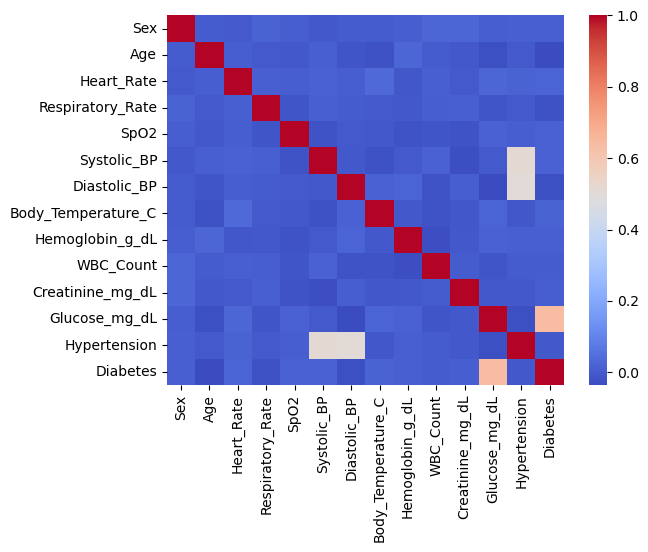

In [108]:
sns.heatmap(data[features]. corr(), cmap="coolwarm")
plt.show()

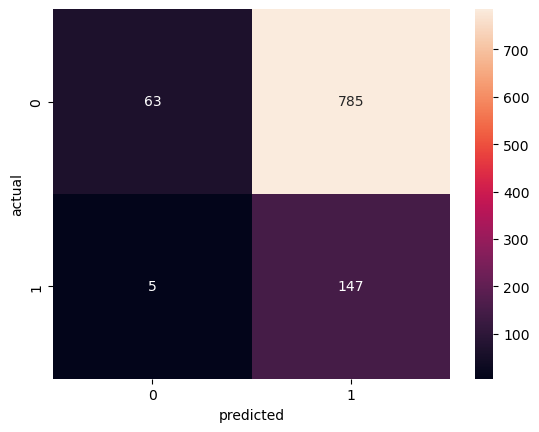

In [112]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

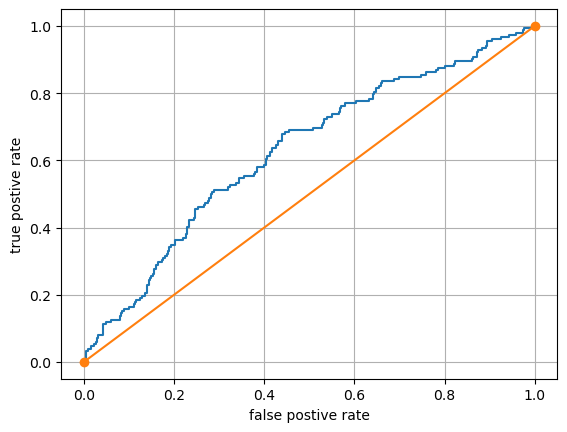

In [114]:
from sklearn.metrics import roc_curve
fpr, tpr, _ =roc_curve(y_test, y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"-",marker="o")
plt.xlabel("false postive rate")
plt.ylabel("true postive rate")
plt.grid()
plt.show()


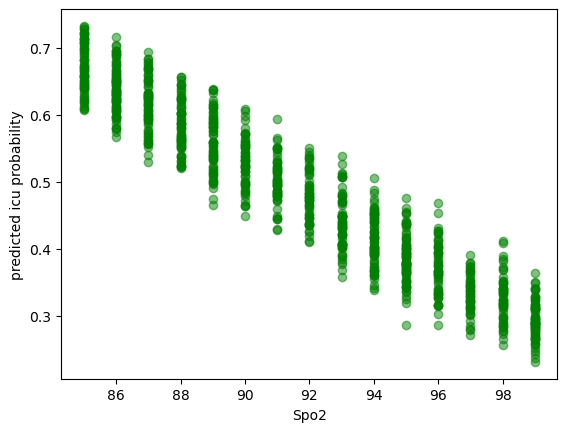

In [118]:

plt.scatter(x_test["SpO2"],y_prob,alpha=0.5, c="green")
plt.plot(kind="line")
plt.xlabel("Spo2")
plt.ylabel("predicted icu probability")
plt.show()

In [149]:
icu_non_icu= data.groupby("ICU_Required").agg(
    age=("Age","mean"),
    spo2=("SpO2","mean"),
    bill_amount=("Total_Bill_Amount","mean"),
    length_stay=("Length_of_Stay_Days","mean")
).round(2)


In [151]:
icu_non_icu

,age,spo2,bill_amount,length_stay
ICU_Required,,,,
0,53.58,92.24,9696.61,4.00
1,52.87,90.15,27313.72,7.12


In [159]:
icu=data[data["ICU_Required"]==0]
non_icu=data[data["ICU_Required"]==1]

In [163]:
comparison=pd.DataFrame({
    "iCu":icu[["Age","SpO2","Total_Bill_Amount","Length_of_Stay_Days"]].mean(),
    "no_icu":non_icu[["Age","SpO2","Total_Bill_Amount","Length_of_Stay_Days"]].mean()
})

In [181]:
comparison.round(3)

,iCu,no_icu
Age,53.576,52.865
SpO2,92.240,90.149
Total_Bill_Amount,9696.605,27313.720
Length_of_Stay_Days,3.998,7.119


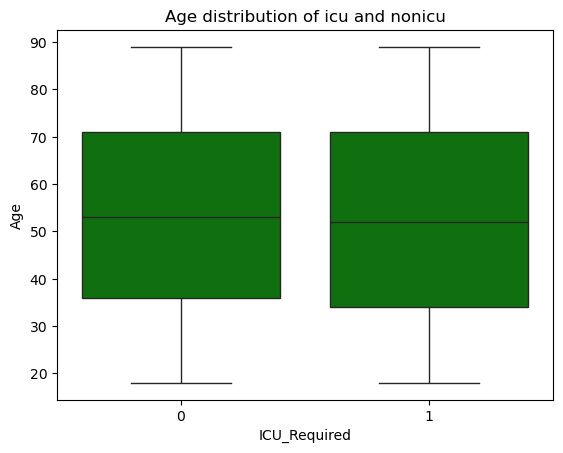

In [191]:
sns.boxplot(x="ICU_Required", y="Age",data=data,color="green")
plt.title("Age distribution of icu and nonicu")
plt.show()

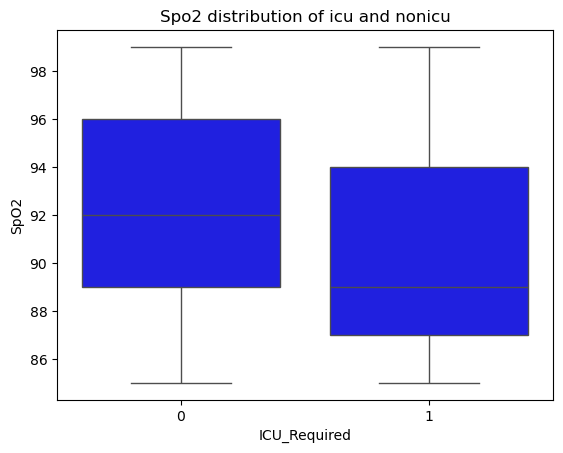

In [193]:
sns.boxplot(x="ICU_Required", y="SpO2",data=data,color="blue")
plt.title("Spo2 distribution of icu and nonicu")
plt.show()

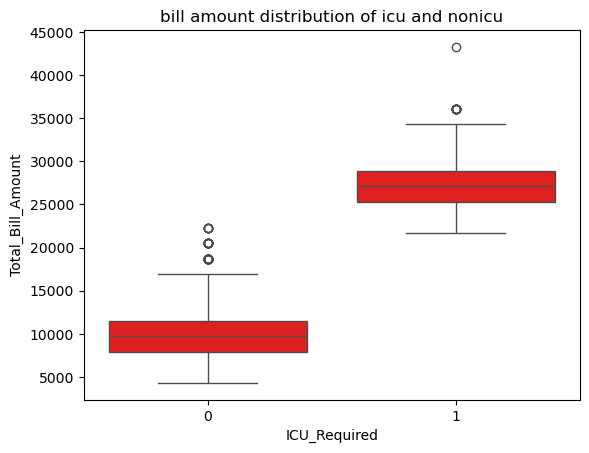

In [195]:
sns.boxplot(x="ICU_Required", y="Total_Bill_Amount",data=data,color="red")
plt.title("bill amount distribution of icu and nonicu")
plt.show()

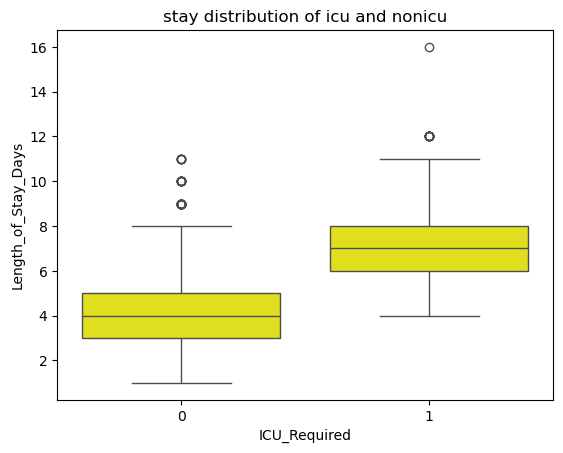

In [207]:
sns.boxplot(x="ICU_Required", y="Length_of_Stay_Days",data=data,color="yellow")
plt.title("stay distribution of icu and nonicu")
plt.show()

In [211]:
admission_hour=data["Admission_Hour"].value_counts().sort_index()
admission_hour

Admission_Hour
0     198
1     195
2     213
3     200
4     200
5     226
6     238
7     215
8     207
9     189
10    208
11    195
12    210
13    211
14    214
15    211
16    217
17    219
18    189
19    206
20    212
21    200
22    207
23    220
Name: count, dtype: int64

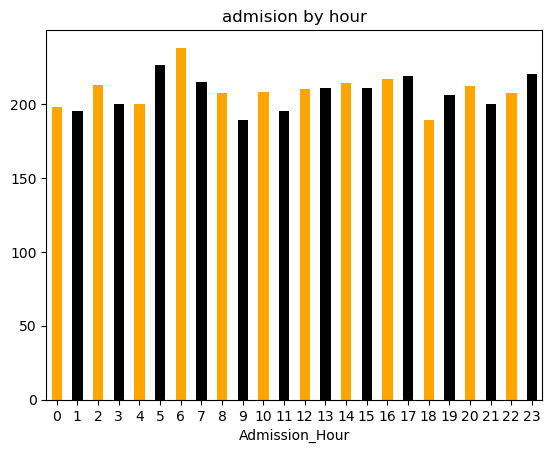

In [219]:
admission_hour.plot(kind="bar",color=("orange","black"))
plt.title("admision by hour")
plt.xticks(rotation=360)
plt.show()

In [253]:
icu_admission_hour=data.groupby("Admission_Hour")["ICU_Required"].mean()*100
icu_admission_hour.round(2)

Admission_Hour
0     16.67
1     15.90
2     10.33
3     14.00
4     13.00
5     15.93
6     16.39
7     13.02
8     16.91
9     19.58
10    10.58
11    20.51
12    13.81
13    16.11
14    13.08
15    13.74
16    17.97
17    14.61
18    13.23
19    15.53
20    16.51
21    16.50
22    13.04
23    17.27
Name: ICU_Required, dtype: float64

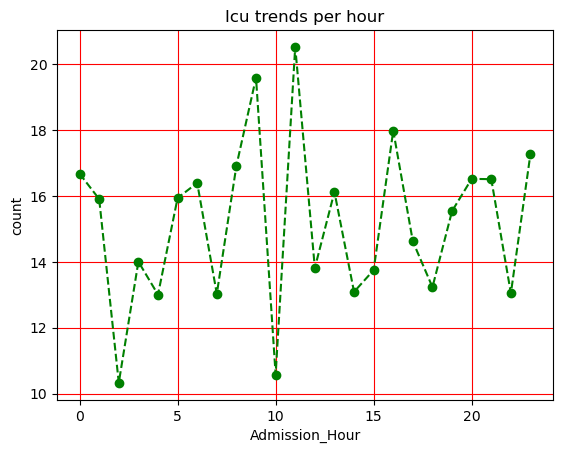

In [331]:
icu_admission_hour.plot(kind="line",marker="o",color="green",linestyle="--")
plt.title("Icu trends per hour")
plt.ylabel("count")
plt.grid(color="red")
plt.show()

In [257]:
bill_thresshold=data["Total_Bill_Amount"].quantile(0.80)
bill_thresshold

15100.0

In [333]:
high_cost_df=data[data["Total_Bill_Amount"]>=bill_thresshold]
high_cost_df

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Mortality,Total_Bill_Amount,Admission_Time,Admission_Date,Admission_Hour,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score
2,PAT200002,75,0,Asian,Secondary,Middle,1,0,Moderate,5.7,...,0,23500,2024-10-31 22:00:00,2024-10-31,22,Thursday,61-75,1,0,4
4,PAT200004,50,0,White,Primary,High,0,0,Moderate,5.6,...,0,16900,2023-10-18 19:00:00,2023-10-18,19,Wednesday,46-60,1,0,1
6,PAT200006,43,0,Hispanic,Primary,High,1,0,High,7.9,...,0,20500,2024-02-17 23:00:00,2024-02-17,23,Saturday,31-45,1,0,2
7,PAT200007,54,1,Black,Secondary,Middle,0,0,Low,8.6,...,0,15100,2024-09-07 14:00:00,2024-09-07,14,Saturday,46-60,1,1,3
12,PAT200012,20,0,White,Secondary,Low,0,0,Low,5.9,...,0,22300,2024-03-27 16:00:00,2024-03-27,16,Wednesday,18-30,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4968,PAT204968,42,0,Hispanic,Secondary,High,0,1,Low,6.7,...,0,30700,2023-10-27 11:00:00,2023-10-27,11,Friday,31-45,1,1,2
4971,PAT204971,60,1,Hispanic,Secondary,Low,0,0,Moderate,6.9,...,0,27100,2024-07-08 03:00:00,2024-07-08,3,Monday,46-60,1,1,2
4974,PAT204974,56,0,Other,Secondary,Low,0,1,Moderate,7.3,...,0,23500,2023-05-05 19:00:00,2023-05-05,19,Friday,46-60,1,0,1
4979,PAT204979,71,0,Hispanic,Graduate,High,0,0,Moderate,4.9,...,0,32500,2024-11-27 03:00:00,2024-11-27,3,Wednesday,61-75,1,0,3


In [335]:
high_cost_df["Sex"].value_counts()

Sex
0    548
1    546
2     29
Name: count, dtype: int64

In [265]:
len(high_cost_df),len(data)

(1123, 5000)

In [269]:
high_icu_rate=high_cost_df["ICU_Required"].mean()*100
high_icu_rate

67.49777382012466

In [273]:
overall_icu_rate=data["ICU_Required"].mean()*100
overall_icu_rate

15.160000000000002

In [503]:
avg_comparison=data.groupby("ICU_Required")["Total_Bill_Amount"].mean().round(2)
avg_comparison

ICU_Required
0     9696.61
1    27313.72
Name: Total_Bill_Amount, dtype: float64

In [295]:
total_cost=data["Total_Bill_Amount"].sum()
high_cost_total=high_cost_df["Total_Bill_Amount"].sum()

In [339]:
(total_cost/high_cost_total)*100

232.3390281383736

In [379]:
percent_bill_diag=data.groupby("Primary_Diagnosis")["Total_Bill_Amount"].sum()
percent_bill_diag

Primary_Diagnosis
Cardiac          8412100
Diabetes        10344300
Hypertension    13297500
Infection        8135200
Neurology        5592500
Orthopedic       3464500
Other            3531300
Respiratory      9059400
Name: Total_Bill_Amount, dtype: int64

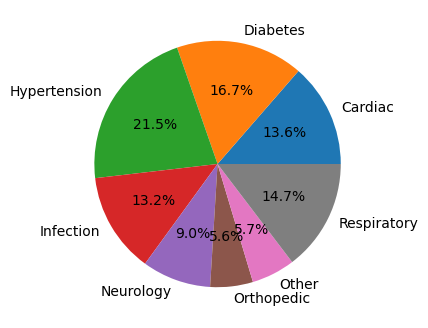

In [383]:
plt.figure(figsize=(10,4))
plt.pie(percent_bill_diag,labels=percent_bill_diag.index,autopct="%1.1f%%")
plt.show()

In [395]:
features=["Age","Sex","Smoking_Status","Alcohol_Consumption"]
x=data[features]
y=data["Hypertension"]

In [397]:
from sklearn.model_selection import train_test_split

In [399]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.20,random_state=100,stratify=y
)

In [401]:
x_train

,Age,Sex,Smoking_Status,Alcohol_Consumption
4413,48,1,1,0
951,38,0,0,0
2130,30,0,0,1
1747,87,1,0,0
3448,37,1,0,0
...,...,...,...,...
4541,43,1,0,1
2930,87,0,0,1
1800,85,0,0,0
1345,70,1,0,0


In [407]:
from sklearn.preprocessing import StandardScaler

In [7]:
scalar=StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

NameError: name 'StandardScaler' is not defined

In [421]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=2000,class_weight="balanced")
lr.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [5]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=300,max_depth=12)
rf.fit(x_train,y_train)

NameError: name 'x_train' is not defined

In [461]:
y_train_pred=rf.predict(x_train)
y_train_pred

4000

In [443]:
y_test_pred=rf.predict(x_test)

In [471]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score,r2_score,classification_report

In [445]:
print(confusion_matrix(y_train,y_train_pred))

[[ 660  402]
 [ 905 2033]]


In [449]:
print(roc_auc_score(y_train,y_train_pred))

0.65671812563218


In [467]:
y_prob=lr.predict_proba(x_test_scaled)[:,1]
y_pred=(y_prob>=0.3).astype(int)

In [469]:
print(confusion_matrix(y_test,y_pred))

[[  0 266]
 [  0 734]]


In [473]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       266
           1       0.73      1.00      0.85       734

    accuracy                           0.73      1000
   macro avg       0.37      0.50      0.42      1000
weighted avg       0.54      0.73      0.62      1000



C:\Users\Pavan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pavan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pavan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


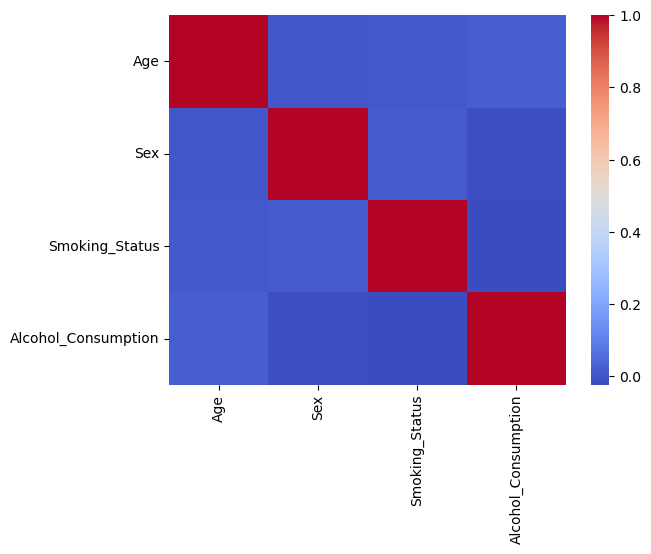

In [475]:
sns.heatmap(data[features].corr(),cmap="coolwarm")
plt.show()

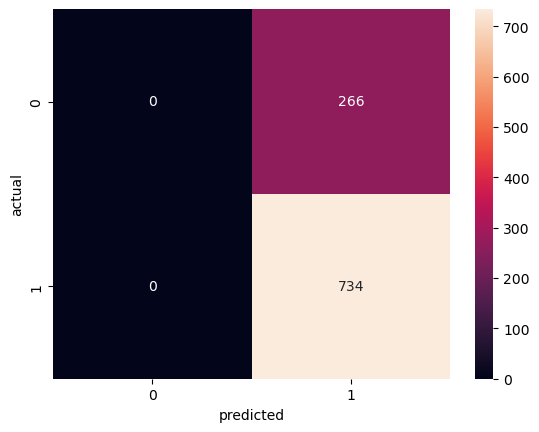

In [479]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

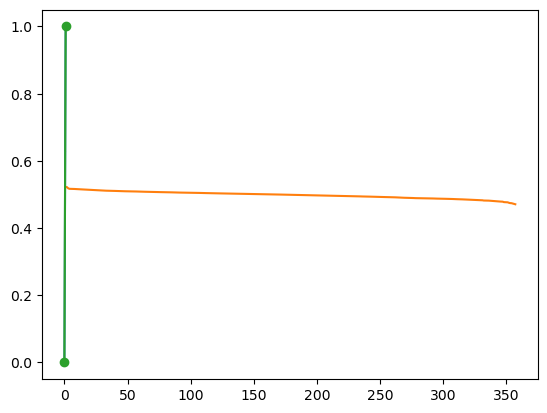

In [509]:
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,_)
plt.plot([0,1],[0,1],"-",marker="o")
plt.show()

In [120]:
plt.scatter(x_test["Alcohol_Consumption"],y_prob,alpha=0.5)
plt.plot(kind="line")
plt.show()

KeyError: 'Alcohol_Consumption'

In [142]:
comparision_icu_non_icu_mean=data.groupby("ICU_Required").agg(
    age=("Age","mean"),
    spo2=("SpO2","mean"),
    len_stay=("Length_of_Stay_Days","mean"),
    total_bill=("Total_Bill_Amount","mean")
)

In [144]:
comparision_icu_non_icu_mean

,age,spo2,len_stay,total_bill
ICU_Required,,,,
0,53.575672,92.239510,3.998114,9696.605375
1,52.865435,90.149077,7.118734,27313.720317


In [148]:
comparision_icu_non_icu_median=data.groupby("ICU_Required").agg(
    age=("Age","median"),
    spo2=("SpO2","median"),
    len_stay=("Length_of_Stay_Days","median"),
     total_bill=("Total_Bill_Amount","median")
)

In [150]:
comparision_icu_non_icu_median

,age,spo2,len_stay,total_bill
ICU_Required,,,,
0,53.0,92.0,4.0,9700.0
1,52.0,89.0,7.0,27100.0


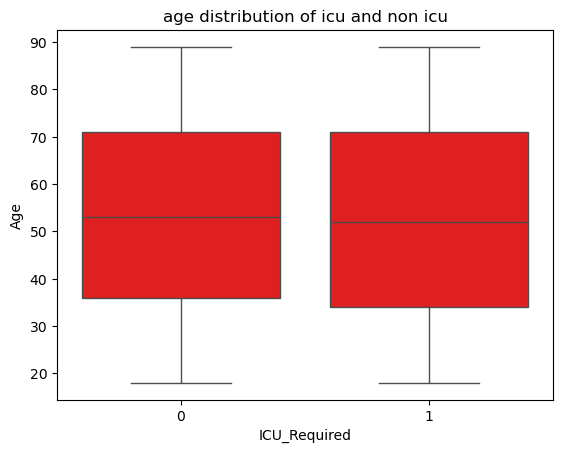

In [160]:
sns.boxplot(x="ICU_Required",y="Age",data=data, color="red")
plt.title("age distribution of icu and non icu")
plt.show()

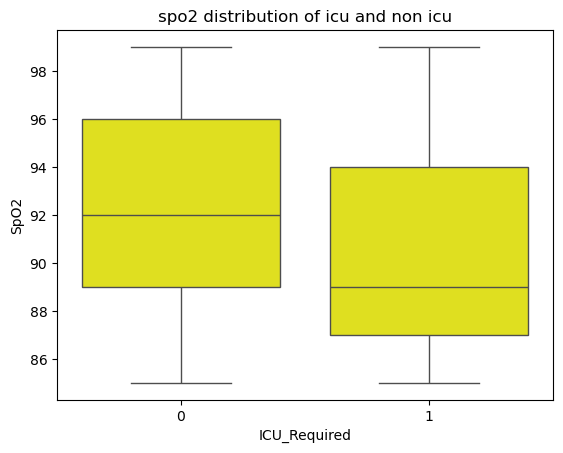

In [158]:
sns.boxplot(x="ICU_Required",y="SpO2",data=data, color="yellow")
plt.title("spo2 distribution of icu and non icu")
plt.show()

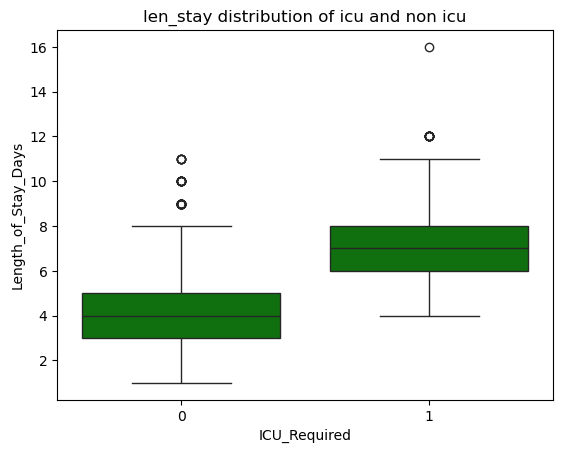

In [156]:
sns.boxplot(x="ICU_Required",y="Length_of_Stay_Days",data=data, color="green")
plt.title("len_stay distribution of icu and non icu")
plt.show()

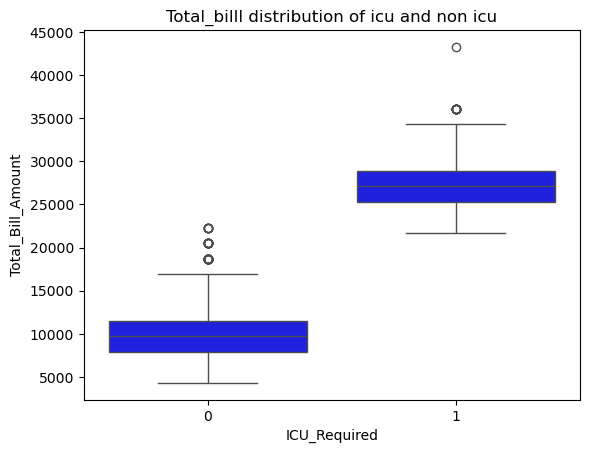

In [164]:
sns.boxplot(x="ICU_Required",y="Total_Bill_Amount",data=data, color="blue")
plt.title("Total_billl distribution of icu and non icu")
plt.show()

In [180]:
diag_cost_avg=(data.groupby("Primary_Diagnosis")["Total_Bill_Amount"].mean().sort_values(ascending=False))
diag_cost_avg.round(2)

Primary_Diagnosis
Neurology       13740.79
Cardiac         13589.82
Respiratory     13129.57
Infection       12034.32
Hypertension    11883.38
Diabetes        11768.26
Other           11654.46
Orthopedic      11285.02
Name: Total_Bill_Amount, dtype: float64

In [194]:
diag_cost_total=(data.groupby("Primary_Diagnosis")["Total_Bill_Amount"].sum().sort_values(ascending=False))
diag_cost_total

Primary_Diagnosis
Hypertension    13297500
Diabetes        10344300
Respiratory      9059400
Cardiac          8412100
Infection        8135200
Neurology        5592500
Other            3531300
Orthopedic       3464500
Name: Total_Bill_Amount, dtype: int64

In [190]:
top_5_diag=diag_cost_avg.head(5)
top_5_diag

Primary_Diagnosis
Neurology       13740.786241
Cardiac         13589.822294
Respiratory     13129.565217
Infection       12034.319527
Hypertension    11883.378016
Name: Total_Bill_Amount, dtype: float64

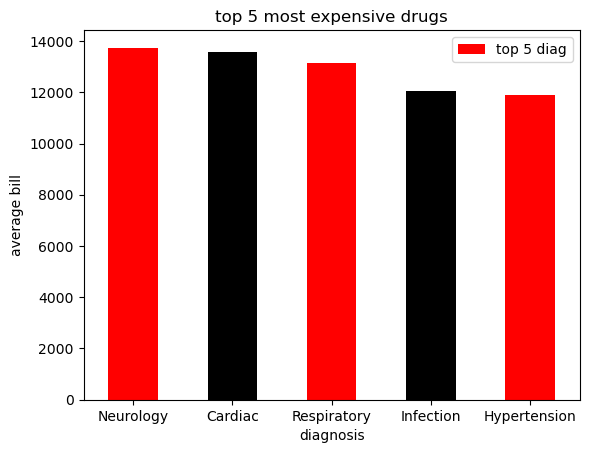

In [218]:
top_5_diag.plot(kind="bar",label="top 5 diag",color=("red","black"))
plt.title("top 5 most expensive drugs")
plt.xlabel("diagnosis")
plt.ylabel("average bill")
plt.legend()
plt.xticks(rotation=0)
plt.show()

In [244]:
data["Age_Group"]=pd.cut(
    data["Age"],
    bins=[0,18,40,60,100],
    labels=["pediaterics","young age","middle age","elder"],
    include_lowest=True
)

In [246]:
los_by_age=data.groupby("Age_Group")["Length_of_Stay_Days"].mean()
los_by_age

C:\Users\Pavan\AppData\Local\Temp\ipykernel_18332\4184184823.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  los_by_age=data.groupby("Age_Group")["Length_of_Stay_Days"].mean()


Age_Group
pediaterics    4.507463
young age      4.576671
middle age     4.433839
elder          4.416008
Name: Length_of_Stay_Days, dtype: float64

In [242]:
los_by_icu=data.groupby("ICU_Required")["Length_of_Stay_Days"].mean()
los_by_icu

ICU_Required
0    3.998114
1    7.118734
Name: Length_of_Stay_Days, dtype: float64

In [254]:
los_by_diag=data.groupby("Primary_Diagnosis")["Length_of_Stay_Days"].mean().sort_values(ascending=False)
los_by_diag

Primary_Diagnosis
Neurology       4.754300
Cardiac         4.663974
Respiratory     4.591304
Hypertension    4.432529
Infection       4.428994
Other           4.359736
Diabetes        4.329920
Orthopedic      4.185668
Name: Length_of_Stay_Days, dtype: float64

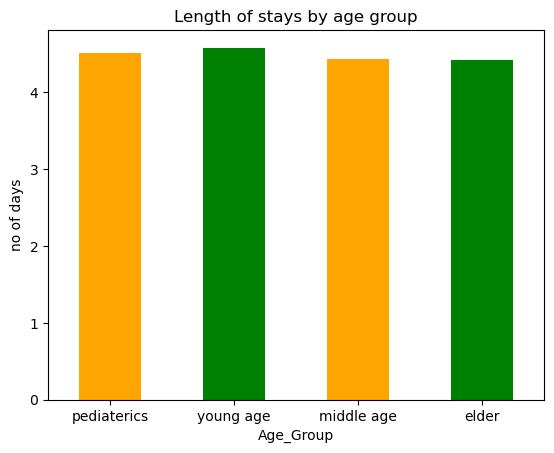

In [262]:
los_by_age.plot(kind="bar",color=("orange","green"))
plt.title("Length of stays by age group")
plt.ylabel("no of days")
plt.xticks(rotation=0)
plt.show()

In [300]:
high_risk=data[(data["Age"]>=65)&(data["SpO2"]<=90)*(data["ICU_Required"]==1)].shape[0]
high_risk

151

In [334]:
data["high_risk_patient"]=(
    (data["Age"]>=65).astype(int)+
    (data["SpO2"]<=90).astype(int)+
    (data["ICU_Required"]==1)
)

In [336]:
data["high_risk_patient"].value_counts()

high_risk_patient
1    2094
0    1749
2    1006
3     151
Name: count, dtype: int64

In [338]:
data["high_risk_patient"].mean()

0.9118

In [342]:
avg_bill_high_risk=data.groupby("high_risk_patient")["Total_Bill_Amount"].mean()
avg_bill_high_risk.round(2)

high_risk_patient
0     9689.71
1    11290.83
2    17014.51
3    27350.33
Name: Total_Bill_Amount, dtype: float64

In [354]:
bill_tresshold=data["Total_Bill_Amount"].quantile(0.80)
top_20_percent=data[data["Total_Bill_Amount"]>=bill_tresshold]

In [358]:
top_20_percent

,Patient_ID,Age,Sex,Race_Ethnicity,Education_Level,Income_Level,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Duration_Hours,...,Day_of_Week,Age_Group,High_BP_Flag,High_Glucose_Flag,Comorbidity_Score,high_risk,top_10%_bill,Age_Band,bill_band,high_risk_patient
2,PAT200002,75,0,Asian,Secondary,Middle,1,0,Moderate,5.7,...,Thursday,elder,1,0,4,184,0,60+,high,3
4,PAT200004,50,0,White,Primary,High,0,0,Moderate,5.6,...,Wednesday,middle age,1,0,1,184,0,46–60,high,1
6,PAT200006,43,0,Hispanic,Primary,High,1,0,High,7.9,...,Saturday,middle age,1,0,2,184,0,31–45,high,1
7,PAT200007,54,1,Black,Secondary,Middle,0,0,Low,8.6,...,Saturday,middle age,1,1,3,184,0,46–60,high,0
12,PAT200012,20,0,White,Secondary,Low,0,0,Low,5.9,...,Wednesday,young age,0,0,2,184,0,18–30,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4968,PAT204968,42,0,Hispanic,Secondary,High,0,1,Low,6.7,...,Friday,middle age,1,1,2,184,0,31–45,high,2
4971,PAT204971,60,1,Hispanic,Secondary,Low,0,0,Moderate,6.9,...,Monday,middle age,1,1,2,184,0,46–60,high,1
4974,PAT204974,56,0,Other,Secondary,Low,0,1,Moderate,7.3,...,Friday,middle age,1,0,1,184,0,46–60,high,1
4979,PAT204979,71,0,Hispanic,Graduate,High,0,0,Moderate,4.9,...,Wednesday,elder,1,0,3,184,0,60+,high,3


In [364]:
top_20_percent["ICU_Required"].mean()*100

67.49777382012466

In [372]:
icu_diag=(
    data.groupby("Primary_Diagnosis")["ICU_Required"]
    .mean()
    .sort_values(ascending=False)
)

In [378]:
icu_diag.head(10)

Primary_Diagnosis
Cardiac         0.224556
Neurology       0.223587
Respiratory     0.197101
Infection       0.130178
Diabetes        0.122867
Hypertension    0.117069
Other           0.108911
Orthopedic      0.104235
Name: ICU_Required, dtype: float64

In [380]:
los_diag=(
    data.groupby("Primary_Diagnosis")["Length_of_Stay_Days"]
    .mean()
    .sort_values(ascending=False)
)

In [382]:
los_diag.head(10)

Primary_Diagnosis
Neurology       4.754300
Cardiac         4.663974
Respiratory     4.591304
Hypertension    4.432529
Infection       4.428994
Other           4.359736
Diabetes        4.329920
Orthopedic      4.185668
Name: Length_of_Stay_Days, dtype: float64

In [384]:
bill_diag=(
    data.groupby("Primary_Diagnosis")["Total_Bill_Amount"]
    .mean()
    .sort_values(ascending=False)
)

In [386]:
print(bill_diag.head(10))

Primary_Diagnosis
Neurology       13740.786241
Cardiac         13589.822294
Respiratory     13129.565217
Infection       12034.319527
Hypertension    11883.378016
Diabetes        11768.259386
Other           11654.455446
Orthopedic      11285.016287
Name: Total_Bill_Amount, dtype: float64


In [398]:
los_10_days=data["Length_of_Stay_Days"]>10
los_10_days.value_counts()

Length_of_Stay_Days
False    4964
True       36
Name: count, dtype: int64

In [430]:
los_age=pd.crosstab(data["Age_Group"],data["Length_of_Stay_Days"]>10)
los_age

Length_of_Stay_Days,False,True
Age_Group,,
pediaterics,66,1
young age,1512,14
middle age,1375,8
elder,2011,13


In [436]:
los_diag=pd.crosstab(data["Primary_Diagnosis"],data["Length_of_Stay_Days"]>10)
los_diag

Length_of_Stay_Days,False,True
Primary_Diagnosis,,
Cardiac,615,4
Diabetes,873,6
Hypertension,1114,5
Infection,674,2
Neurology,402,5
Orthopedic,304,3
Other,299,4
Respiratory,683,7


In [454]:
icu_rate_los=data.groupby("ICU_Required")["Length_of_Stay_Days"].mean()*100
icu_rate_los.round(1)

ICU_Required
0    399.8
1    711.9
Name: Length_of_Stay_Days, dtype: float64